In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
dir = 'data'

train_df = pd.read_pickle(f"{dir}/train_data.pkl")
test_df = pd.read_pickle(f"{dir}/test_data.pkl")

### Fixing mismatching column names

In [3]:
train_df.shape, test_df.shape

((6589448, 41), (8004840, 42))

In [4]:
train_columns = train_df.columns
test_columns = test_df.columns

In [5]:
train_only = train_columns.difference(test_columns)

test_only = test_columns.difference(train_columns)

print("Only in train:")
print(train_only)

print("\nOnly in test:")
print(test_only)

Only in train:
Index([], dtype='str')

Only in test:
Index(['smart_22_raw'], dtype='str')


In [6]:
test_df = test_df.drop(columns=['smart_22_raw'])

In [7]:
print( list(train_df.columns) == list(test_df.columns) )

True


In [8]:
test_df = test_df[train_columns]

In [9]:
test_df.head(1)

,date,serial_number,model,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,...,smart_200_raw,smart_222_raw,smart_223_raw,smart_225_raw,smart_226_raw,smart_240_raw,smart_241_raw,smart_242_raw,smart_250_raw,smart_251_raw
0,2017-07-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,3000592982016,0,0.0,107.0,554.0,16.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
train_df.head(1)

,date,serial_number,model,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,...,smart_200_raw,smart_222_raw,smart_223_raw,smart_225_raw,smart_226_raw,smart_240_raw,smart_241_raw,smart_242_raw,smart_250_raw,smart_251_raw
0,2016-10-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,3000592982016,0,0.0,108.0,554.0,15.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Transformation of temporal variables

In [11]:
def sort_date(df):

    df['date'] = pd.to_datetime(df['date'])

    return df.sort_values( by='date', ascending=True).reset_index(drop=True)

In [12]:
train_df = sort_date(train_df)

In [13]:
test_df = sort_date(test_df)

In [14]:
train_df['date'].dtype, test_df['date'].dtype

(dtype('<M8[us]'), dtype('<M8[us]'))

### Selecting Important features

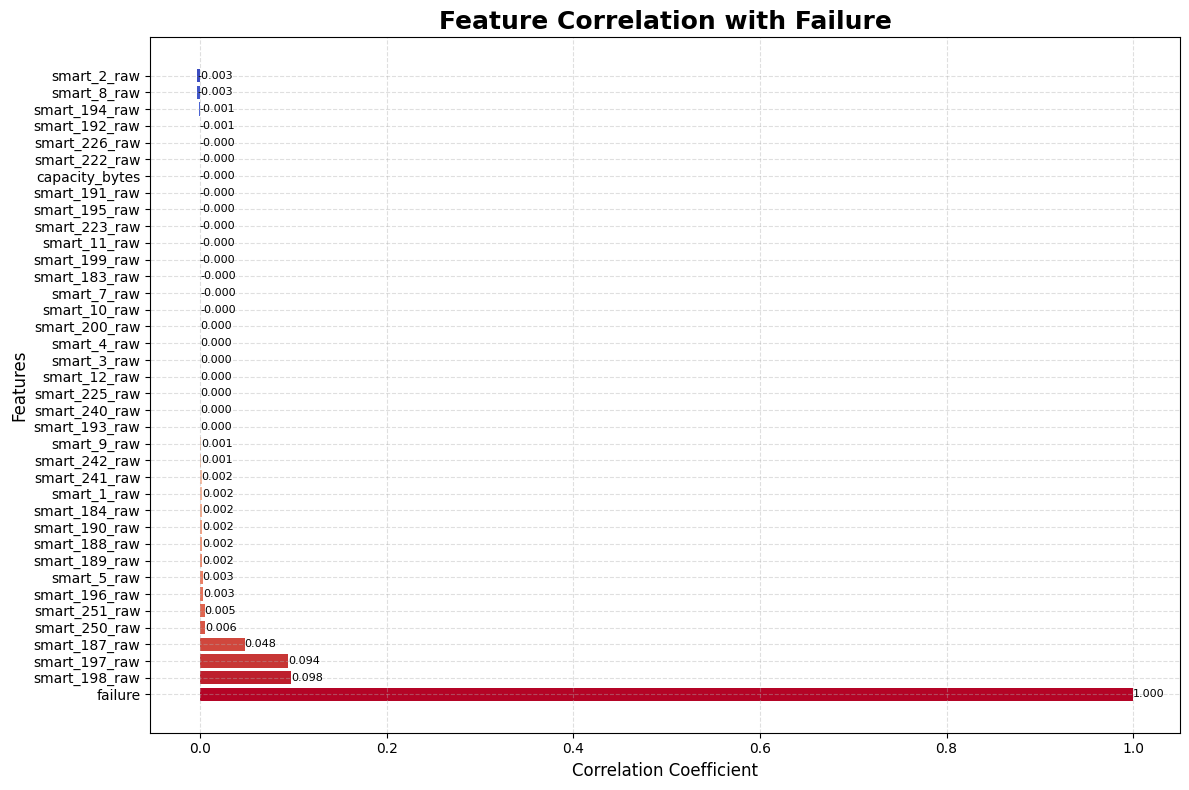

In [16]:
failure_corr = train_df.corr(numeric_only=True)['failure'].sort_values(ascending=False)

plt.figure(figsize=(12,8))

bars = plt.barh(
    failure_corr.index,
    failure_corr.values,
    color=plt.cm.coolwarm( np.linspace(1, 0, len(failure_corr)) )
)

plt.title(
    'Feature Correlation with Failure',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Correlation Coefficient',
    fontsize=12
)

plt.ylabel(
    'Features',
    fontsize=12
)

plt.grid(
    linestyle='--',
    alpha=0.4
)

for bar in bars:
    
    width = bar.get_width()
    
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}',
        va='center',
        fontsize=8
    )

plt.tight_layout()

plt.show()

In [17]:
X = train_df.drop(columns=['failure'])
X = X.select_dtypes(include=np.number)

y = train_df['failure']

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values( by='Importance', ascending=False )

importance_df.head(50)

,Feature,Importance
8,smart_9_raw,1.173283e-01
24,smart_197_raw,8.893923e-02
33,smart_241_raw,8.252747e-02
34,smart_242_raw,8.215403e-02
6,smart_7_raw,7.691699e-02
20,smart_193_raw,7.607594e-02
1,smart_1_raw,6.882276e-02
32,smart_240_raw,6.426679e-02
25,smart_198_raw,6.042658e-02
21,smart_194_raw,3.871313e-02


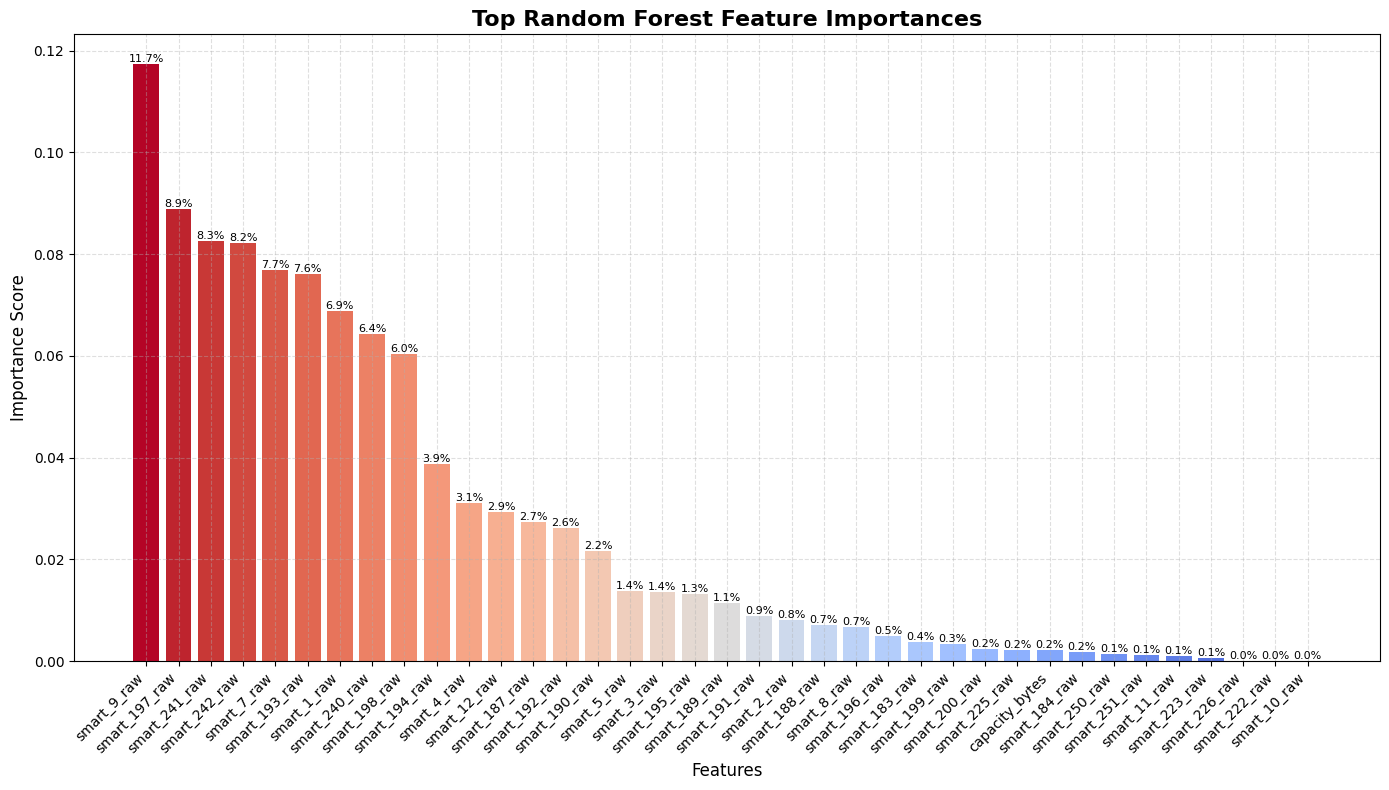

In [32]:
top_features = importance_df.head(50)

plt.figure(figsize=(14,8))

bars = plt.bar(
    top_features['Feature'],
    top_features['Importance'],
    color=plt.cm.coolwarm(
        np.linspace(1, 0, len(top_features))
    )
)

plt.title(
    'Top Random Forest Feature Importances',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.grid(
    linestyle='--',
    alpha=0.4
)

for bar in bars:
    
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{(height/1)*100:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=0
    )

plt.tight_layout()

plt.show()

In [36]:
len(importance_df)

37

In [47]:
importance_df['Feature'].head(28).tolist()

['smart_9_raw',
 'smart_197_raw',
 'smart_241_raw',
 'smart_242_raw',
 'smart_7_raw',
 'smart_193_raw',
 'smart_1_raw',
 'smart_240_raw',
 'smart_198_raw',
 'smart_194_raw',
 'smart_4_raw',
 'smart_12_raw',
 'smart_187_raw',
 'smart_192_raw',
 'smart_190_raw',
 'smart_5_raw',
 'smart_3_raw',
 'smart_195_raw',
 'smart_189_raw',
 'smart_191_raw',
 'smart_2_raw',
 'smart_188_raw',
 'smart_8_raw',
 'smart_196_raw',
 'smart_183_raw',
 'smart_199_raw',
 'smart_200_raw',
 'smart_225_raw']

In [15]:
important_features = ['smart_9_raw',
 'smart_197_raw',
 'smart_241_raw',
 'smart_242_raw',
 'smart_7_raw',
 'smart_193_raw',
 'smart_1_raw',
 'smart_240_raw',
 'smart_198_raw',
 'smart_194_raw',
 'smart_4_raw',
 'smart_12_raw',
 'smart_187_raw',
 'smart_192_raw',
 'smart_190_raw',
 'smart_5_raw',
 'smart_3_raw',
 'smart_195_raw',
 'smart_189_raw',
 'smart_191_raw',
 'smart_2_raw',
 'smart_188_raw',
 'smart_8_raw',
 'smart_196_raw',
 'smart_183_raw',
 'smart_199_raw',
 'smart_200_raw',
 'smart_225_raw']

In [ ]:
def remove_low_importance_features(df, importance_df):

    selected_features = importance_df.head(28)['Feature'].tolist()

    metadata_features = [
        col for col in df.columns
        if 'smart' not in col
    ]

    return df[selected_features + metadata_features]

In [ ]:
train_df1 = remove_low_importance_features(train_df, importance_df)
test_df1 = remove_low_importance_features(test_df, importance_df)

In [19]:
train_df1.shape, test_df1.shape

((6589448, 33), (8004840, 33))

### Extracting failed drives

In [20]:
failed_drives = train_df.loc[ train_df1['failure'] == 1, 'serial_number' ].unique().tolist()

failed_train_df = train_df[ train_df1['serial_number'].isin(failed_drives) ]

failed_train_df.groupby('serial_number').size().sort_values(ascending=False)

serial_number
ZA10Q2F7          92
Z305D4X6          92
S301LJ5G          92
Z30111PC          92
ZA10QN09          91
                  ..
Z3025KXS           1
Z301YAWQ           1
PL2331LAHD88GJ     1
Z305Y09F           1
ZA10B3RV           1
Length: 349, dtype: int64

In [21]:
from sklearn.preprocessing import MinMaxScaler

sensors = [
    'smart_9_raw','smart_197_raw','smart_241_raw','smart_242_raw',
    'smart_7_raw','smart_193_raw','smart_1_raw','smart_240_raw',
    'smart_198_raw','smart_194_raw','smart_4_raw','smart_12_raw',
    'smart_187_raw','smart_192_raw'
]

sample_norm = sample.copy()

scaler = MinMaxScaler()
sample_norm[sensors] = scaler.fit_transform(sample_norm[sensors])

failure_date = sample_norm.loc[
    sample_norm['failure'] == 1, 'date'
].min()

df_melt = sample_norm.melt(
    id_vars=['date', 'failure'],
    value_vars=sensors,
    var_name='sensor',
    value_name='value'
)

df_melt_before = df_melt[df_melt['date'] <= failure_date]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_melt_before,
    x='date',
    y='value',
    hue='sensor'
)

plt.axvline(
    x=failure_date,
    color='red',
    linestyle='--',
    label='Failure Point'
)

plt.title("Normalized Multi-Sensor Evolution Until Failure")
plt.legend()
plt.show()

NameError: name 'sample' is not defined

In [22]:
def prepare_drive_datasets(df, n_normal_drives=500):

    #failed
    
    failed_drives = df.loc[ df['failure'] == 1, 'serial_number' ].unique().tolist()

    failed_df = df[ df['serial_number'].isin(failed_drives) ]


    #normal
    
    normal_df = df[~df['serial_number'].isin(failed_drives)]

    normal_counts = normal_df['serial_number'].value_counts()

    selected_normal_drives = normal_counts.head(n_normal_drives).index.tolist()

    normal_df = normal_df[normal_df['serial_number'].isin(selected_normal_drives)]


    final_df = pd.concat([failed_df, normal_df],ignore_index=True)




    print(f'Failed drives: {len(failed_drives)}')
    print(f'Selected normal drives: {len(selected_normal_drives)}')

    print( 'Disjoint sets:', set(failed_drives).isdisjoint(set(selected_normal_drives)))

    return final_df, failed_drives, selected_normal_drives

In [23]:
train_df2, train_failed_drives, train_selected_normal_drives = prepare_drive_datasets(train_df1)

Failed drives: 349
Selected normal drives: 500
Disjoint sets: True


In [24]:
test_df2, test_failed_drives, test_selected_normal_drives = prepare_drive_datasets(test_df1)

Failed drives: 392
Selected normal drives: 500
Disjoint sets: True


In [25]:
train_df2.shape,  test_df2.shape

((61351, 33), (62632, 33))

<Axes: xlabel='failure'>

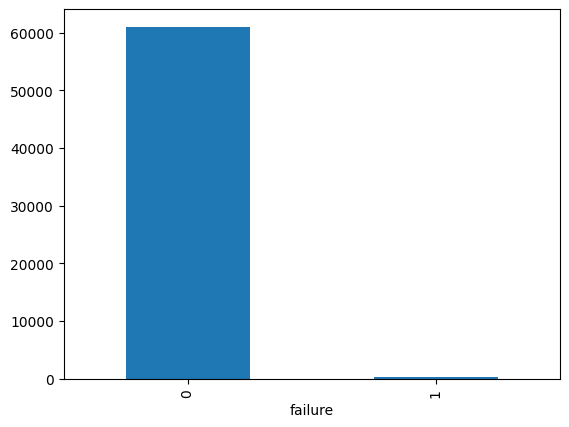

In [26]:
train_df2['failure'].value_counts().plot(kind='bar')

<Axes: xlabel='failure'>

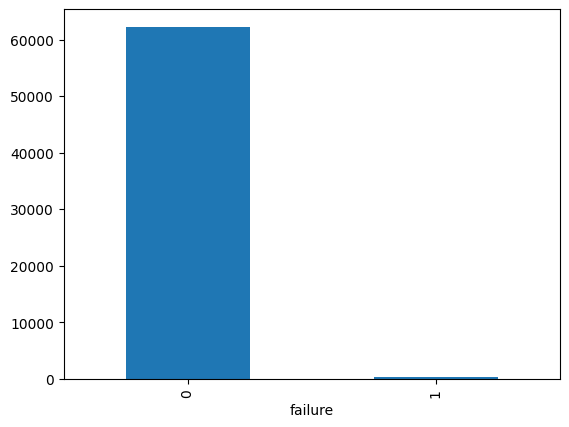

In [27]:
test_df2['failure'].value_counts().plot(kind='bar')

### Fixing missing days between records

In [28]:
def adjust_dates(df):

    df = df.sort_values('date')

    full_range = pd.date_range(
        start=df['date'].min(),
        end=df['date'].max(),
        freq='D'
    )

    df = df.set_index('date').reindex(full_range)

    df.index.name = 'date'
    df = df.reset_index()

    df['serial_number'] = df['serial_number'].ffill()
    df = df.ffill()

    return df

In [29]:
def correct_all_drives(df):

    corrected_dfs = []

    for drive in df['serial_number'].unique():

        drive_df = df[df['serial_number'] == drive]

        corrected_drive = adjust_dates(drive_df)

        corrected_dfs.append(corrected_drive)

    final_corrected_df = pd.concat(corrected_dfs, ignore_index=True)

    return final_corrected_df

In [30]:
train_corrected_df = correct_all_drives(train_df2)

In [31]:
test_corrected_df = correct_all_drives(test_df2)

In [32]:
train_corrected_df.shape, test_corrected_df.shape

((61371, 33), (62742, 33))

### Normilazing

In [34]:
scaler = MinMaxScaler()

feature_cols = [col for col in train_corrected_df.columns if 'smart' in col]

train_corrected_df[feature_cols] = scaler.fit_transform(train_corrected_df[feature_cols])
test_corrected_df[feature_cols] = scaler.transform(test_corrected_df[feature_cols])

In [38]:
train_corrected_df.describe()

,date,smart_9_raw,smart_197_raw,smart_241_raw,smart_242_raw,smart_7_raw,smart_193_raw,smart_1_raw,smart_240_raw,smart_198_raw,...,smart_2_raw,smart_188_raw,smart_8_raw,smart_196_raw,smart_183_raw,smart_199_raw,smart_200_raw,smart_225_raw,capacity_bytes,failure
count,61371,61371.000000,61371.000000,61371.000000,61371.000000,61371.000000,61371.000000,61371.000000,6.137100e+04,61371.000000,...,61371.000000,61371.000000,61371.000000,61371.000000,61371.000000,61371.000000,61371.000000,61371.00000,6.137100e+04,61371.000000
mean,2016-11-11 16:08:53.567972,0.365999,0.000071,0.370638,0.006652,0.003160,0.026448,0.041581,3.880471e-02,0.000099,...,0.211029,0.000177,0.117864,0.005059,0.005571,0.001819,0.001840,0.00255,4.267705e+12,0.005687
min,2016-10-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.600419e+11,0.000000
25%,2016-10-20 00:00:00,0.170301,0.000000,0.000000,0.000000,0.000000,0.000343,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,4.000787e+12,0.000000
50%,2016-11-10 00:00:00,0.356770,0.000000,0.466637,0.000897,0.001034,0.007133,0.030565,3.038343e-11,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,4.000787e+12,0.000000
75%,2016-12-04 00:00:00,0.521868,0.000000,0.608881,0.014050,0.001957,0.030373,0.077894,8.331014e-11,0.000000,...,0.718750,0.000000,0.351648,0.000000,0.000000,0.000000,0.000000,0.00000,4.000787e+12,0.000000
max,2016-12-31 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,8.001563e+12,1.000000
std,NaN,0.226391,0.004570,0.302690,0.021986,0.024431,0.065301,0.042831,1.561292e-01,0.004121,...,0.352856,0.010861,0.197941,0.060777,0.036325,0.038959,0.032911,0.04020,1.363220e+12,0.075196


In [39]:
test_corrected_df.describe()

,date,smart_9_raw,smart_197_raw,smart_241_raw,smart_242_raw,smart_7_raw,smart_193_raw,smart_1_raw,smart_240_raw,smart_198_raw,...,smart_2_raw,smart_188_raw,smart_8_raw,smart_196_raw,smart_183_raw,smart_199_raw,smart_200_raw,smart_225_raw,capacity_bytes,failure
count,62742,62742.000000,62742.000000,62742.000000,62742.000000,62742.000000,62742.000000,62742.000000,6.274200e+04,62742.000000,...,62742.000000,62742.000000,62742.000000,62742.000000,62742.000000,62742.000000,62742.000000,62742.000000,6.274200e+04,62742.000000
mean,2017-08-11 03:28:30.662713,0.375751,0.000110,0.483116,0.007163,0.003221,0.037961,0.044612,1.199692e-02,0.000210,...,0.210397,0.000002,0.121694,0.000590,0.038732,0.000113,0.001893,0.000409,4.752443e+12,0.006248
min,2017-07-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.374390e+11,0.000000
25%,2017-07-19 00:00:00,0.194097,0.000000,0.000000,0.000000,0.000000,0.000366,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000787e+12,0.000000
50%,2017-08-09 00:00:00,0.337068,0.000000,0.592614,0.003921,0.001699,0.004894,0.037065,4.103237e-11,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000787e+12,0.000000
75%,2017-09-02 00:00:00,0.574185,0.000000,0.760625,0.009592,0.002513,0.043257,0.081584,7.575781e-11,0.000000,...,0.757812,0.000000,0.450549,0.000000,0.000000,0.000000,0.000000,0.000000,4.000787e+12,0.000000
max,2017-09-30 00:00:00,0.885706,0.188993,1.131805,0.046555,0.633752,0.740719,0.126028,9.990233e-01,0.364010,...,1.000000,0.105263,0.494505,0.452659,9.750000,0.034378,0.800922,0.169524,8.001563e+12,1.000000
std,NaN,0.226309,0.001935,0.354779,0.008966,0.020998,0.077683,0.041993,8.833658e-02,0.003726,...,0.352102,0.000433,0.203540,0.012382,0.492100,0.001481,0.034912,0.006918,1.651592e+12,0.078796


### Preparing training sequences

In [40]:
sequence_length = 5
lookahead_days = 1

In [41]:
def create_failed_sequences(df, sequence_length, lookahead_days):

    failed_sequences = []

    failed_drives = df[df['failure'] == 1]['serial_number'].unique()

    for drive in failed_drives:

        df_drive = df[df['serial_number'] == drive].reset_index(drop=True)

        failure_index = df_drive[df_drive['failure'] == 1].index[0]

        end = failure_index - lookahead_days + 1
        start = end - sequence_length

        if start >= 0:

            seq = df_drive.iloc[start:end]
            failed_sequences.append(seq)

    return pd.concat(failed_sequences)

In [42]:
def create_normal_sequences(df, sequence_length):

    normal_sequences = []

    normal_df = df[df['failure'] == 0]

    for drive in normal_df['serial_number'].unique():

        df_drive = normal_df[normal_df['serial_number'] == drive].reset_index(drop=True)

        for i in range(len(df_drive) - sequence_length):

            seq = df_drive.iloc[i:i+sequence_length]
            normal_sequences.append(seq)

    return pd.concat(normal_sequences)

In [43]:
train_corrected_df = train_corrected_df.sort_values(['serial_number', 'date'])

In [44]:
train_failed_seq = create_failed_sequences(train_corrected_df, sequence_length, lookahead_days)
train_normal_seq = create_normal_sequences(train_corrected_df, sequence_length)

train_failed_seq['label'] = 1
train_normal_seq['label'] = 0

train_sequences = pd.concat([train_failed_seq, train_normal_seq]).reset_index(drop=True)

In [45]:
test_failed_seq = create_failed_sequences(test_corrected_df, sequence_length, lookahead_days)
test_normal_seq = create_normal_sequences(test_corrected_df, sequence_length)

test_failed_seq['label'] = 1
test_normal_seq['label'] = 0

test_sequences = pd.concat([test_failed_seq, test_normal_seq]).reset_index(drop=True)

In [46]:
train_sequences.shape, test_sequences.shape

((285980, 34), (291575, 34))

In [47]:
set(train_sequences.columns) == set(test_sequences.columns)

True

In [48]:
train_sequences.columns.equals(test_sequences.columns)

True

In [49]:
dir = 'data'

train_sequences.to_pickle(f"{dir}/train_sequences.pkl")
test_sequences.to_pickle(f"{dir}/test_sequences.pkl")